In [1]:
import pandas as pd
import numpy as np

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
boundaries_df = pd.read_csv("/scratch1/smaruj/boundary_disruption_data.tsv", sep="\t")

In [7]:
len(boundaries_df.groupby(['chrom', 'start', 'end']))

4474

In [8]:
4474 - 3915

559

In [9]:
# restricting the window to +-28kb
window_types = [f"down{i}" for i in range(12,0,-1)] + [f"tad{i}" for i in range(1,6)] + [f"up{i}" for i in range(1,13)]
boundaries_df = boundaries_df[boundaries_df['type'].isin(window_types)].reset_index(drop=True)

In [10]:
# order of disrupted bins from downstream to upstream
type_order = [f"down{i}" for i in range(12,0,-1)] + [f"tad{i}" for i in range(1,6)] + [f"up{i}" for i in range(1,13)]

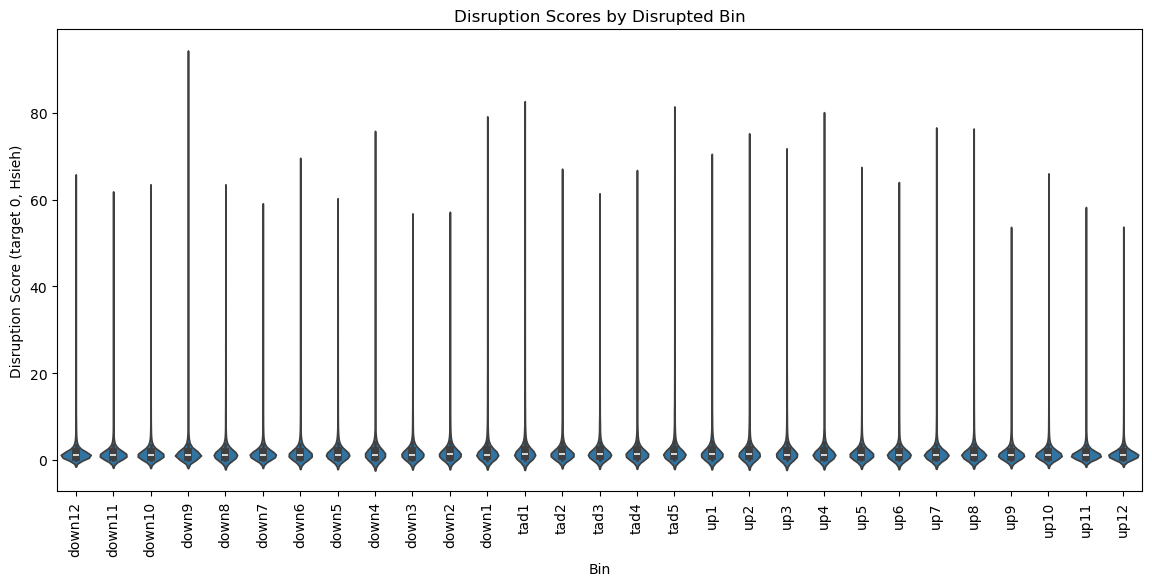

In [11]:
# Set up the figure
plt.figure(figsize=(14, 6))

# Create the violin plot
sns.violinplot(data=boundaries_df, x='type', y='SCD_h1_m0_t0', inner='box', order=type_order)
# target 1 is Bonev ES Cells, which HiC TAD boundaries have called on

# Add labels and title
plt.xlabel('Bin')
plt.ylabel('Disruption Score (target 0, Hsieh)')
plt.title('Disruption Scores by Disrupted Bin')
plt.xticks(rotation=90)

# Show the plot
plt.show()

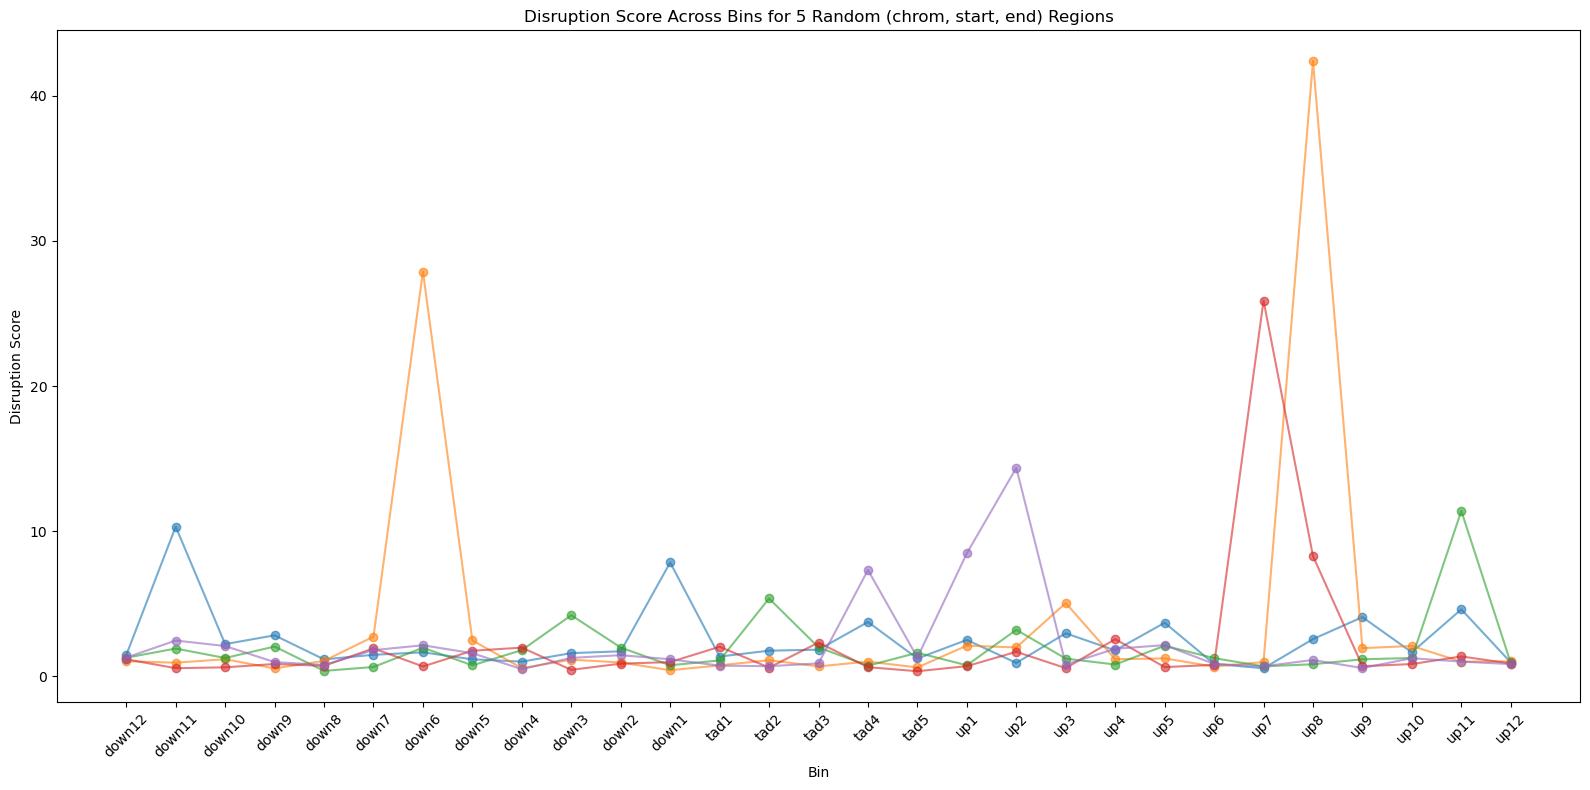

In [12]:
# Randomly sample 100 unique (chrom, start, end) regions
sampled_df = boundaries_df.drop_duplicates(subset=['chrom', 'start', 'end']).sample(n=5)

# Filter the original dataframe to include only the sampled regions
filtered_df = boundaries_df[boundaries_df[['chrom', 'start', 'end']].apply(tuple, axis=1).isin(sampled_df[['chrom', 'start', 'end']].apply(tuple, axis=1))]

# Set up the figure
plt.figure(figsize=(16, 8))

# Create a mapping from type to order
type_mapping = {t: i for i, t in enumerate(type_order)}

# For each sampled region, plot the line connecting SCD values for each type
for (chrom, start, end), group in filtered_df.groupby(['chrom', 'start', 'end']):
    # Sort the group by the defined type order
    group = group.sort_values(by='type', key=lambda x: x.map(type_mapping))
    plt.plot(group['type'], group['SCD_h1_m0_t1'], marker='o', label=f"{chrom}:{start}-{end}", alpha=0.6)

# Add labels and title
plt.xlabel('Bin')
plt.ylabel('Disruption Score')
plt.title('Disruption Score Across Bins for 5 Random (chrom, start, end) Regions')

plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()

# Show the plot
plt.show()

In [13]:
from skimage.filters import threshold_li

In [14]:
thresholds_li = threshold_li(boundaries_df['SCD_h1_m0_t0'].values.astype('float32'))

In [15]:
thresholds_li

6.7396045

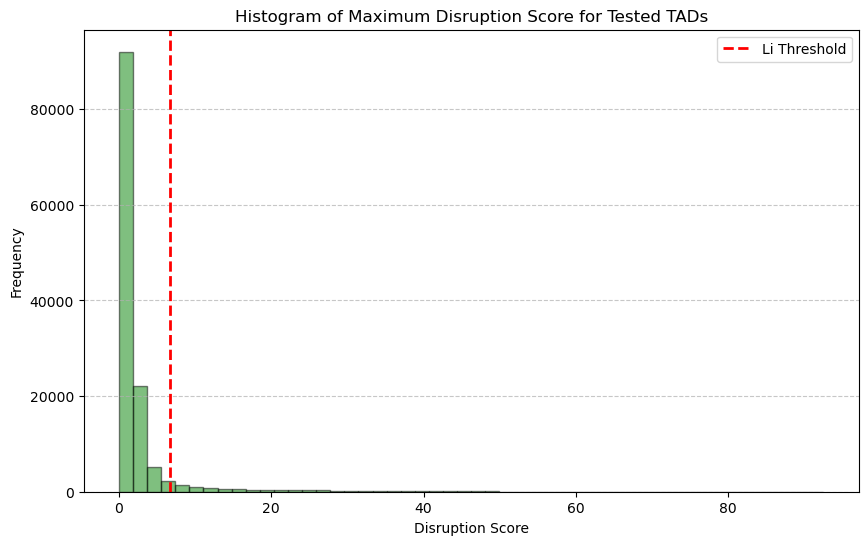

In [16]:
plt.figure(figsize=(10, 6))

# Plotting the histogram for explained_tads
plt.hist(boundaries_df['SCD_h1_m0_t0'], bins=50, alpha=0.5, color='green', edgecolor='black')

# thresholds_li = threshold_li(result_df['SCD_h1_m0_t1'].values)

plt.axvline(thresholds_li, color='red', linestyle='dashed', linewidth=2, label='Li Threshold')

# # Adding labels and title
plt.xlabel('Disruption Score')
plt.ylabel('Frequency')
plt.title('Histogram of Maximum Disruption Score for Tested TADs')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# plt.savefig("./plots/max_disruption_threshold.pdf", format="pdf")

# Show the plot
plt.show()

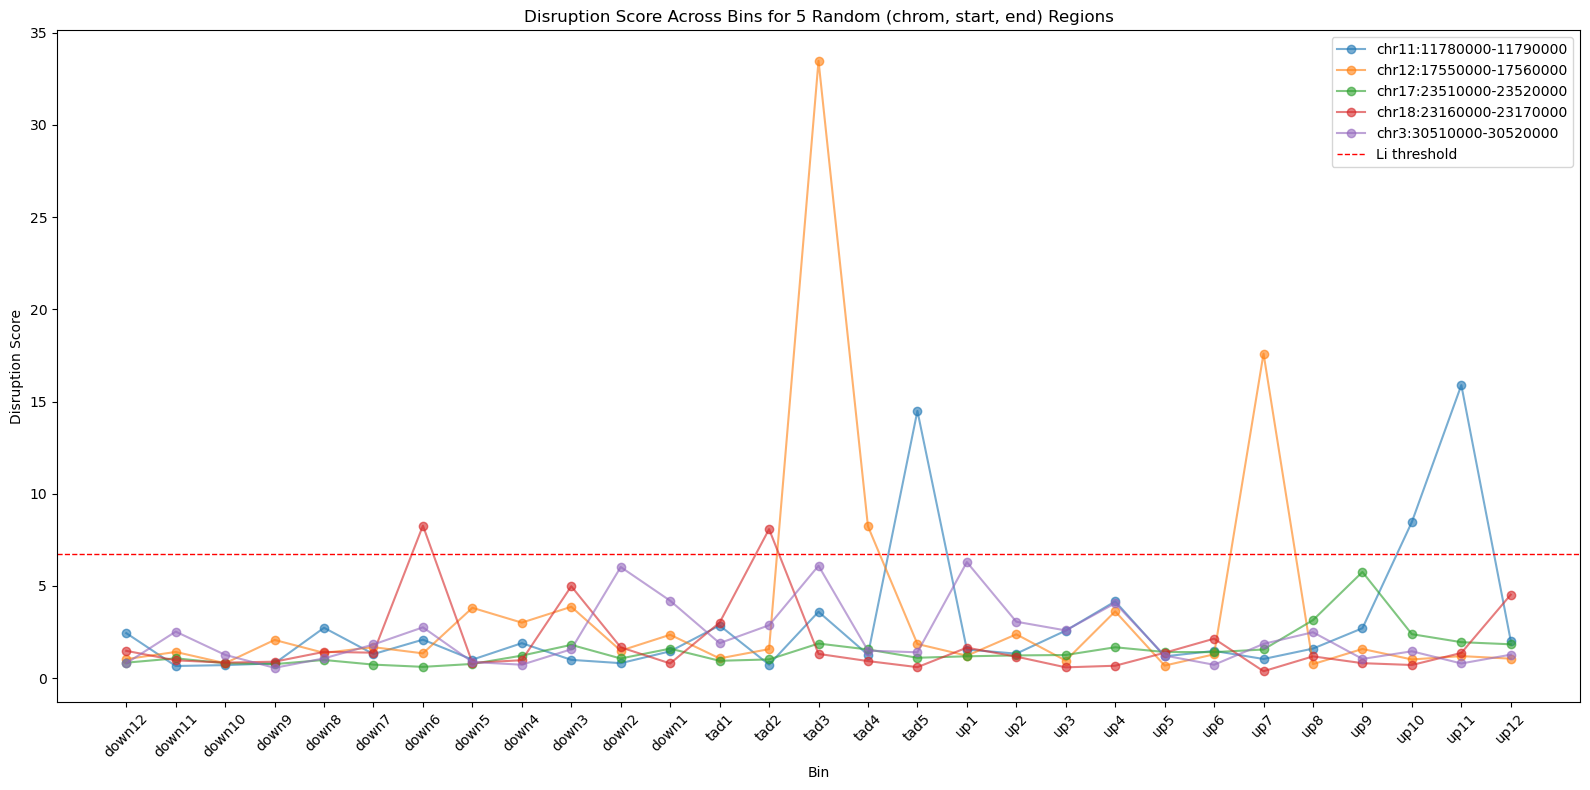

In [17]:
# Randomly sample 100 unique (chrom, start, end) regions
sampled_df = boundaries_df.drop_duplicates(subset=['chrom', 'start', 'end']).sample(n=5)

# Filter the original dataframe to include only the sampled regions
filtered_df = boundaries_df[boundaries_df[['chrom', 'start', 'end']].apply(tuple, axis=1).isin(sampled_df[['chrom', 'start', 'end']].apply(tuple, axis=1))]

# Set up the figure
plt.figure(figsize=(16, 8))

# Create a mapping from type to order
type_mapping = {t: i for i, t in enumerate(type_order)}

# For each sampled region, plot the line connecting SCD values for each type
for (chrom, start, end), group in filtered_df.groupby(['chrom', 'start', 'end']):
    # Sort the group by the defined type order
    group = group.sort_values(by='type', key=lambda x: x.map(type_mapping))
    plt.plot(group['type'], group['SCD_h1_m0_t1'], marker='o', label=f"{chrom}:{start}-{end}", alpha=0.6)

# Add labels and title
plt.xlabel('Bin')
plt.ylabel('Disruption Score')
plt.title('Disruption Score Across Bins for 5 Random (chrom, start, end) Regions')

plt.axhline(y=thresholds_li, color='red', linestyle='--', linewidth=1, label='Li threshold')
plt.legend()
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()

# Show the plot
plt.show()

In [18]:
sensitive_bins = boundaries_df[boundaries_df["SCD_h1_m0_t0"] > thresholds_li]

In [19]:
disr_bins = [i for i in range(241, 270)]
# boundary overlapping bins are: 253, 254, 255, 256, 257

In [20]:
type_to_num = dict(zip(type_order, disr_bins))
sensitive_bins['disrupted_bin'] = sensitive_bins['type'].map(type_to_num)

/tmp/SLURM_780420/ipykernel_559861/4202448432.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sensitive_bins['disrupted_bin'] = sensitive_bins['type'].map(type_to_num)


In [21]:
sensitive_bins = sensitive_bins.reset_index(drop=True)

In [22]:
sensitive_bins = sensitive_bins.drop(columns=["rel_disruption_end", "rel_disruption_start", "type"])

In [23]:
sensitive_bins = sensitive_bins.drop(columns=["SCD_h1_m0_t0", "SCD_h1_m0_t1", "SCD_h1_m0_t2", "SCD_h1_m0_t3", "SCD_h1_m0_t4", "SCD_h1_m0_t5"])

In [24]:
grouped_df = (
    sensitive_bins
    .groupby(["chrom", "start", "end", "window_end", "window_start"])["disrupted_bin"]
    .apply(list)
    .reset_index()
)

In [25]:
grouped_df

,chrom,start,end,window_end,window_start,disrupted_bin
0,chr1,4400000,4410000,5061504,3750784,[261]
1,chr1,4770000,4780000,5431504,4120784,"[252, 243, 253, 258]"
2,chr1,5150000,5160000,5811504,4500784,"[247, 269]"
3,chr1,5900000,5910000,6561504,5250784,"[255, 260]"
4,chr1,6190000,6200000,6851504,5540784,[253]
...,...,...,...,...,...,...
3910,chr9,121450000,121460000,122111504,120800784,"[257, 266, 267]"
3911,chr9,121700000,121710000,122361504,121050784,"[251, 243]"
3912,chr9,122350000,122360000,123011504,121700784,[253]
3913,chr9,122720000,122730000,123381504,122070784,"[257, 261]"


In [ ]:
# grouped_df.to_csv("/scratch1/smaruj/sensitive_bins_boundaries.tsv", sep="\t", index=False)